In [1]:

import os
import tarfile
from six.moves import urllib
import warnings
warnings.filterwarnings(action="ignore", module="scipy", message="^internal gelsd")

DOWNLOAD_ROOT="https://raw.githubusercontent.com/ageron/handson-ml/master/"
HOUSING_PATH="datasets/housing"
HOUSING_URL=DOWNLOAD_ROOT+HOUSING_PATH+"/housing.tgz"

def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    if not os.path.isdir(housing_path):
        os.makedirs(housing_path)
    tgz_path=os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url,tgz_path)
    housing_tgz=tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()

In [2]:
fetch_housing_data(HOUSING_URL,HOUSING_PATH)

C:\Users\rachh\AppData\Local\Temp\ipykernel_18044\521803984.py:17: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tgz.extractall(path=housing_path)


In [3]:
import pandas as pd
import numpy as np

csv_path=os.path.join(HOUSING_PATH,"housing.csv")
housing = pd.read_csv(csv_path)

In [4]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Some things to notice:
    The only data missing is the total_bedrooms, which here are 207 data points missing
        ocean proximity is a feature defined as an "object" but we are safe to assume that it is a string, indicating a location in reference to the ocean. (Categorical feature) Every other feature is a float value.
    With that in mind, we want to look at what categories exist for the ocean proximity. We can also plot histogram to look more carefully at the statistical values of each features as shown above.

In [7]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [9]:
#%matplotlib inline
#import matplotlib.pyplot as plt
#housing.hist(bins=50,figsize=(20,10))
#plt.show()

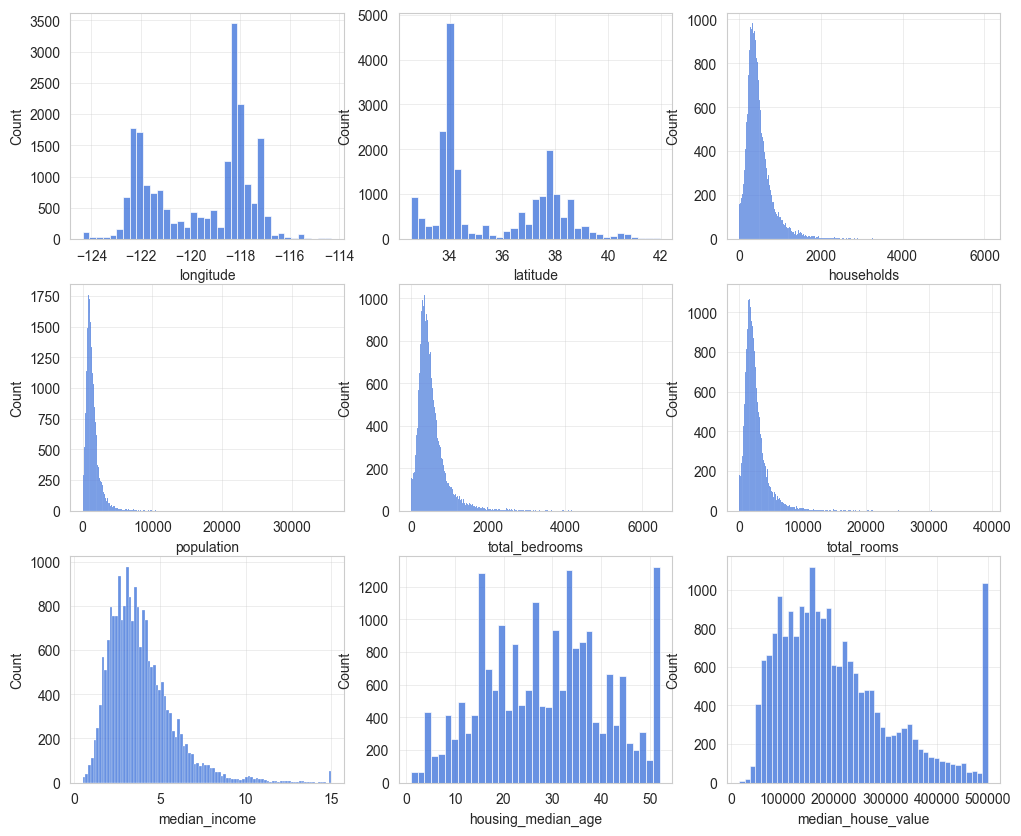

In [15]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.figure(figsize=[12,10])
plt.subplot(331)
sns.histplot(housing['longitude'])
plt.subplot(332)
sns.histplot(housing['latitude'])
plt.subplot(333)
sns.histplot(housing['households'])
plt.subplot(334)
sns.histplot(housing['population'])
plt.subplot(335)
sns.histplot(housing['total_bedrooms'].dropna())
plt.subplot(336)
sns.histplot(housing['total_rooms'])
plt.subplot(337)
sns.histplot(housing['median_income'])
plt.subplot(338)
sns.histplot(housing['housing_median_age'])
plt.subplot(339)
sns.histplot(housing['median_house_value'])
plt.show()


We notice a few things about the data given the graphs:
    1. Housing value and Housing age are capped to a certain max.
    2. Median Income is definitely not in dollars (perhaps in 10000s instead).
    3. A lot of data are tail heavy.
    4. There's not much to be looking at longitudes and latitudes.

Now we can start testing for a model. But first we have to split the data into a training set and a test set.

In [16]:
from sklearn.model_selection import train_test_split

train,test=train_test_split(housing, test_size=0.2)
print('train set size:',len(train),', test set size:',len(test))

train set size: 16512 , test set size: 4128


In [22]:
housing['income_cat']=np.ceil(housing['median_income']/1.5)
#housing['income_cat'].where(housing['income_cat'] < 5, 5.0, inplace=True)
housing.loc[housing['income_cat'] >= 5, 'income_cat'] = 5.0
#housing['income_cat']

In [23]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)
for train_index, test_index in split.split(housing, housing['income_cat']):
    strat_train_set=housing.loc[train_index]
    strat_test_set=housing.loc[test_index]

In [29]:
#print(len(housing))
housing["income_cat"].value_counts()/len(housing)

income_cat
3.0    0.350581
2.0    0.318847
4.0    0.176308
5.0    0.114438
1.0    0.039826
Name: count, dtype: float64

In [30]:
for set_ in (strat_train_set,strat_test_set):
    set_.drop('income_cat',axis=1,inplace=True)

In [31]:
housing = strat_train_set.copy()

Visualizing Data

<Axes: xlabel='longitude', ylabel='latitude'>

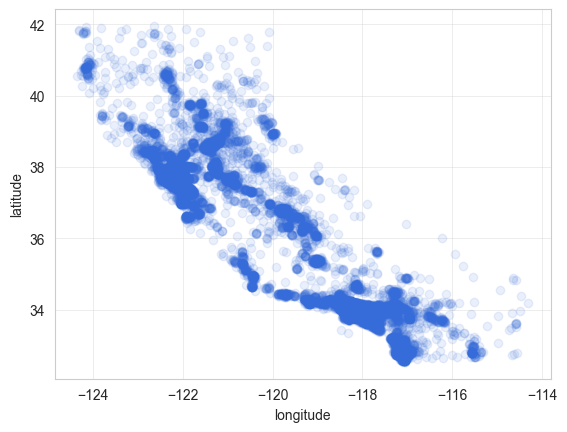

In [36]:
sns.regplot(x='longitude',y='latitude',data=housing, scatter=True, fit_reg=False, scatter_kws={'alpha':0.1})

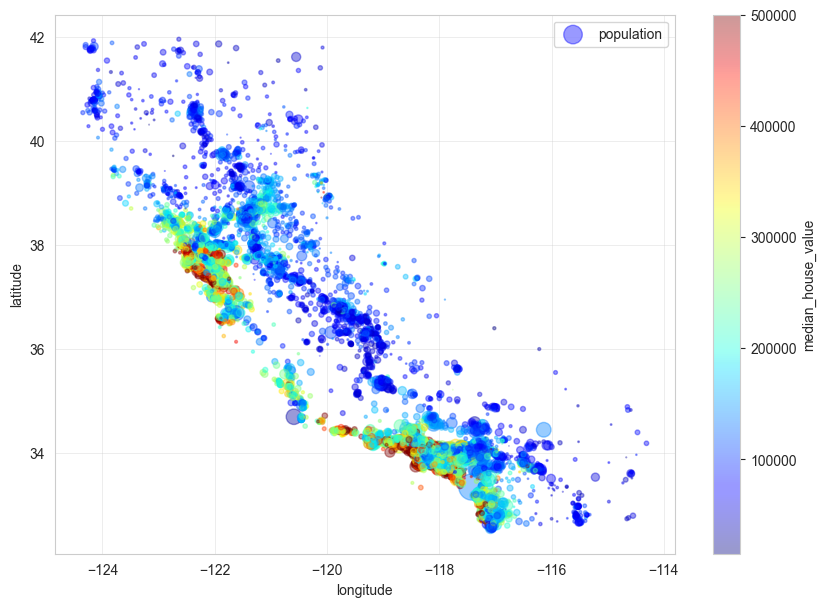

In [37]:
housing.plot(kind='scatter',x='longitude',y='latitude',alpha=.4,s=housing['population']/100,label='population',figsize=(10,7),c='median_house_value',cmap=plt.get_cmap('jet'),colorbar=True)
plt.legend()

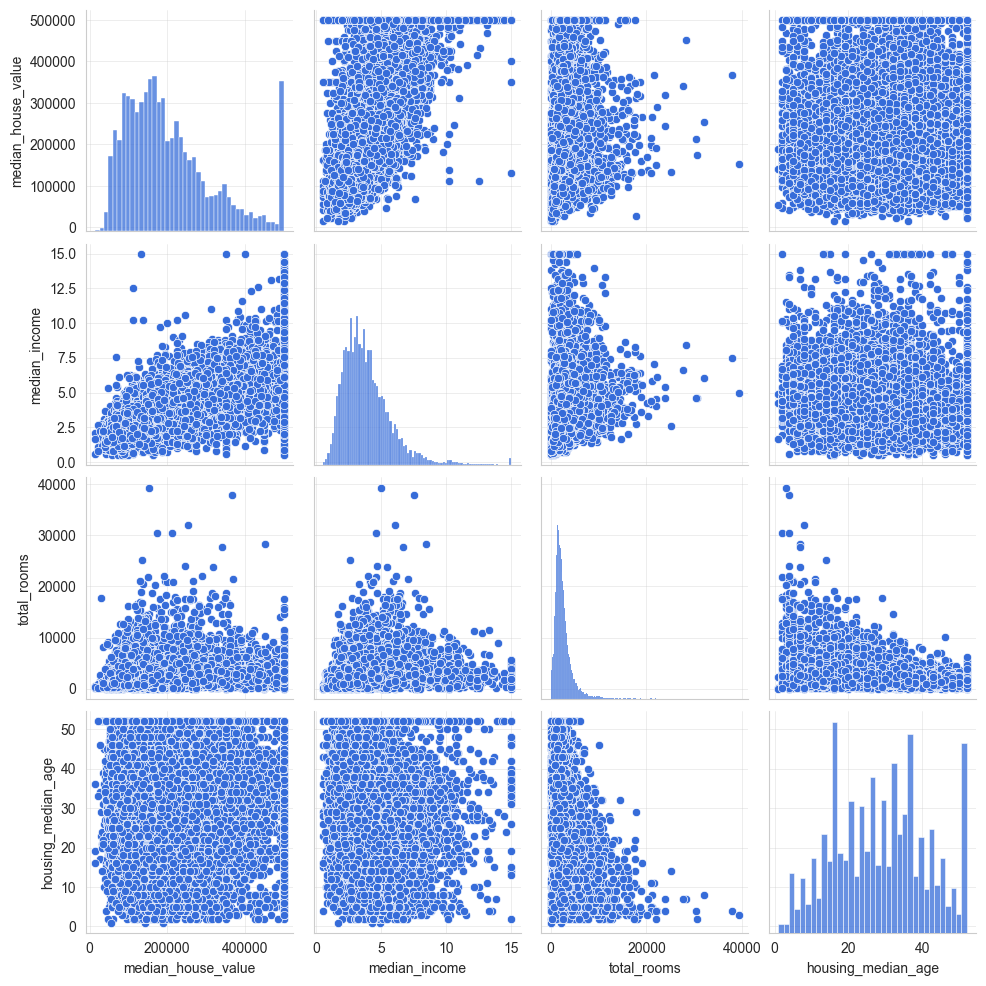

In [38]:
attributes=['median_house_value','median_income','total_rooms','housing_median_age']
sns.pairplot(housing[attributes])